In [18]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

In [ ]:
# Menggunakan dataset hasil clustering yang memiliki fitur Target
df = pd.read_csv("data_clustering_inverse.csv")
 
# Tampilkan 5 baris pertama dengan function head
print(df.head())

    price_in_rp                                              title  \
0  1.250000e+08          Rumah mewah Sertategis di Jatiasih Bekasi   
1  1.980000e+09               Rumah Siap Huni di Summarecon Bekasi   
2  4.800000e+08        Rumah minimalis termurah di jatiasih bekasi   
3  3.000000e+08  Rumah murah di Bekasi, gabus tambun utara Deka...   
4  1.200000e+09  Rumah 2lantai di bekasi kota deket tol bekasi ...   

            district     city  \
0  Summarecon Bekasi   Bekasi   
1  Summarecon Bekasi   Bekasi   
2  Summarecon Bekasi   Bekasi   
3             Bekasi   Bekasi   
4             Bekasi   Bekasi   

                                          facilities property_type  bedrooms  \
0                                              Taman         rumah       3.0   
1  Tempat Jemuran,  Jogging Track,  Track Lari,  ...         rumah       2.0   
2                                    Keamanan, Taman         rumah       2.0   
3   Taman, Ac, AC,  Masjid, Jalur Telepon,  Keamanan        

In [20]:
# Encode semua kolom bertipe object sebelum modeling
for col in df.columns:
    if df[col].dtype == 'object':
        le_tmp  = LabelEncoder()
        df[col] = le_tmp.fit_transform(df[col].astype(str))
 
df['Target'] = df['Target'].astype(int)
 
print(df.dtypes)
print(df.shape)

price_in_rp                 float64
title                         int32
district                      int32
city                          int32
facilities                    int32
property_type                 int32
bedrooms                    float64
bathrooms                   float64
land_size_m2                float64
building_size_m2            float64
carports                    float64
certificate                   int32
electricity                   int32
maid_bedrooms               float64
maid_bathrooms              float64
floors                      float64
building_age                float64
year_built                  float64
property_condition            int32
building_orientation          int32
garages                     float64
furnishing                    int32
price_in_rp_bin               int32
price_in_rp_bin_enc           int64
building_size_m2_bin          int32
building_size_m2_bin_enc      int64
Target                        int32
dtype: object
(729, 27)


In [21]:
# Pembagian Dataset
# Menggunakan train_test_split() untuk melakukan pembagian dataset
X = df.drop(columns=['Target'])
y = df['Target']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
sc         = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)
 
print(f"Data latih: {X_train.shape}")
print(f"Data uji  : {X_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts().sort_index()}")
print(f"\nDistribusi y_test:\n{y_test.value_counts().sort_index()}")

Data latih: (583, 26)
Data uji  : (146, 26)

Distribusi y_train:
Target
0    193
1    113
2    200
3     77
Name: count, dtype: int64

Distribusi y_test:
Target
0    48
1    29
2    50
3    19
Name: count, dtype: int64


In [22]:
# Model 1: Decision Tree
# Membuat model klasifikasi menggunakan Decision Tree
dt        = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

In [23]:
# Menampilkan hasil evaluasi Decision Tree
acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
 
print(f"Akurasi  : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"Presisi  : {prec_dt:.4f}")
print(f"Recall   : {rec_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, zero_division=0))

Akurasi  : 0.9658 (96.58%)
Presisi  : 0.9659
Recall   : 0.9658
F1-Score : 0.9657

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        48
           1       0.97      0.97      0.97        29
           2       0.96      0.98      0.97        50
           3       0.95      0.95      0.95        19

    accuracy                           0.97       146
   macro avg       0.96      0.96      0.96       146
weighted avg       0.97      0.97      0.97       146



In [24]:
# Menyimpan Model Decision Tree
joblib.dump(dt, 'decision_tree_model.h5')
print("Model disimpan: decision_tree_model.h5")

Model disimpan: decision_tree_model.h5


In [25]:
# Model 2: Random Forest Classifier
# Melatih model menggunakan RandomForestClassifier
rf        = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

In [26]:
# Menampilkan hasil evaluasi Random Forest
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
 
print(f"Akurasi  : {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"Presisi  : {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

Akurasi  : 0.9726 (97.26%)
Presisi  : 0.9726
Recall   : 0.9726
F1-Score : 0.9726

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        48
           1       1.00      1.00      1.00        29
           2       0.96      0.96      0.96        50
           3       1.00      1.00      1.00        19

    accuracy                           0.97       146
   macro avg       0.98      0.98      0.98       146
weighted avg       0.97      0.97      0.97       146



In [27]:
# Menyimpan Model Random Forest
joblib.dump(rf, 'explore_RandomForest_classification.h5')
print("Model disimpan: explore_RandomForest_classification.h5")

Model disimpan: explore_RandomForest_classification.h5


In [28]:
# Perbandingan Evaluasi Semua Model
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat
hasil_eval = pd.DataFrame({
    'Model'   : ['Decision Tree', 'Random Forest'],
    'Akurasi' : [acc_dt,  acc_rf],
    'Presisi' : [prec_dt, prec_rf],
    'Recall'  : [rec_dt,  rec_rf],
    'F1-Score': [f1_dt,   f1_rf],
})
print(hasil_eval.to_string(index=False))

        Model  Akurasi  Presisi   Recall  F1-Score
Decision Tree 0.965753 0.965876 0.965753  0.965747
Random Forest 0.972603 0.972603 0.972603  0.972603


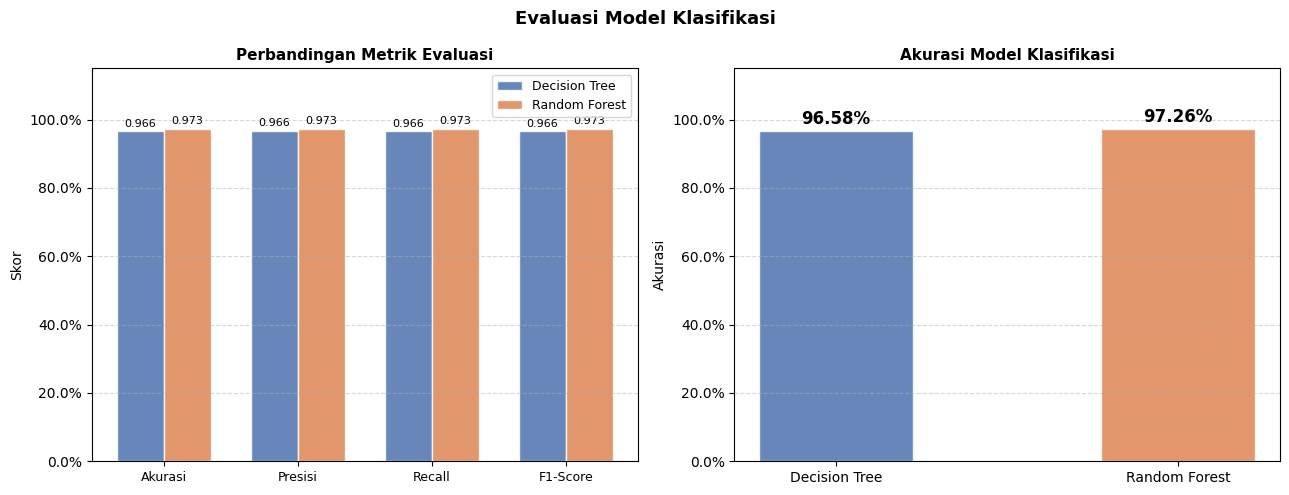

In [29]:
# Visualisasi perbandingan evaluasi Decision Tree vs Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
vals_dt = [acc_dt, prec_dt, rec_dt, f1_dt]
vals_rf = [acc_rf, prec_rf, rec_rf, f1_rf]
x       = np.arange(len(metrics))
w       = 0.35
 
bars1 = axes[0].bar(x - w/2, vals_dt, w, label='Decision Tree',
                    color='#4C72B0', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + w/2, vals_rf, w, label='Random Forest',
                    color='#DD8452', alpha=0.85, edgecolor='white')
axes[0].bar_label(bars1, fmt='%.3f', fontsize=8, padding=2)
axes[0].bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=9)
axes[0].set_ylabel('Skor', fontsize=10)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
 
bars3 = axes[1].bar(['Decision Tree', 'Random Forest'],
                    [acc_dt, acc_rf],
                    color=['#4C72B0', '#DD8452'],
                    width=0.45, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, [acc_dt, acc_rf]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val*100:.2f}%", ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[1].set_ylabel('Akurasi', fontsize=10)
axes[1].set_title('Akurasi Model Klasifikasi', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
 
plt.suptitle('Evaluasi Model Klasifikasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('akurasi_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Hyperparameter Tuning
# Melakukan Hyperparameter Tuning dan Latih ulang
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}
 
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train)
 
best_model   = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_sc)
 
print(f"Best Params  : {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Params  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9691


In [31]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada algoritma yang sudah dituning
acc_tuned  = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
rec_tuned  = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned   = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
 
print(f"Akurasi  : {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"Presisi  : {prec_tuned:.4f}")
print(f"Recall   : {rec_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Akurasi  : 0.9726 (97.26%)
Presisi  : 0.9726
Recall   : 0.9726
F1-Score : 0.9726

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        48
           1       1.00      1.00      1.00        29
           2       0.96      0.96      0.96        50
           3       1.00      1.00      1.00        19

    accuracy                           0.97       146
   macro avg       0.98      0.98      0.98       146
weighted avg       0.97      0.97      0.97       146



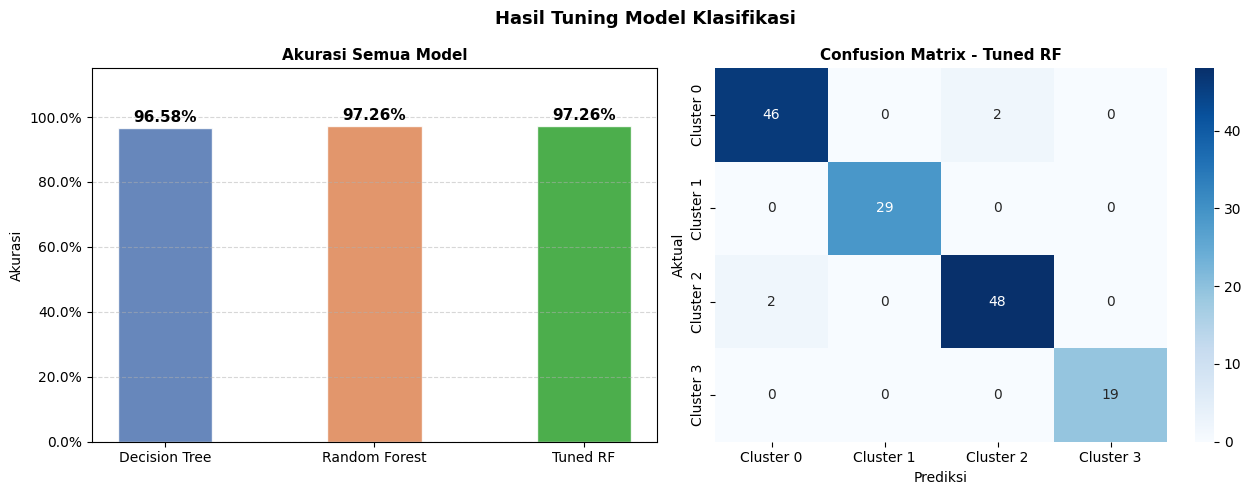

In [32]:
# Visualisasi akurasi semua model termasuk hasil tuning dan confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
all_models = ['Decision Tree', 'Random Forest', 'Tuned RF']
all_acc    = [acc_dt, acc_rf, acc_tuned]
all_colors = ['#4C72B0', '#DD8452', '#2CA02C']
 
bars = axes[0].bar(all_models, all_acc, color=all_colors,
                   width=0.45, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, all_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val*100:.2f}%", ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_ylabel('Akurasi', fontsize=10)
axes[0].set_title('Akurasi Semua Model', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
 
K_OPTIMAL = len(np.unique(y))
cm        = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[f"Cluster {i}" for i in range(K_OPTIMAL)],
            yticklabels=[f"Cluster {i}" for i in range(K_OPTIMAL)])
axes[1].set_xlabel('Prediksi', fontsize=10)
axes[1].set_ylabel('Aktual', fontsize=10)
axes[1].set_title('Confusion Matrix - Tuned RF', fontsize=11, fontweight='bold')
 
plt.suptitle('Hasil Tuning Model Klasifikasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('akurasi_semua_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Menyimpan Model hasil tuning
joblib.dump(best_model, 'tuning_classification.h5')
print("Model disimpan: tuning_classification.h5")

Model disimpan: tuning_classification.h5


In [34]:
# Ringkasan evaluasi seluruh model
hasil_final = pd.DataFrame({
    'Model'   : ['Decision Tree', 'Random Forest', 'Tuned RF'],
    'Akurasi' : [acc_dt,   acc_rf,   acc_tuned],
    'Presisi' : [prec_dt,  prec_rf,  prec_tuned],
    'Recall'  : [rec_dt,   rec_rf,   rec_tuned],
    'F1-Score': [f1_dt,    f1_rf,    f1_tuned],
})
print(hasil_final.to_string(index=False))

        Model  Akurasi  Presisi   Recall  F1-Score
Decision Tree 0.965753 0.965876 0.965753  0.965747
Random Forest 0.972603 0.972603 0.972603  0.972603
     Tuned RF 0.972603 0.972603 0.972603  0.972603
